In [2]:
import pandas as pd
interactions = pd.read_csv("customer_interactions.csv")

print(interactions.head())
print(interactions.shape)
print(interactions.columns)
print(interactions.info())
print(interactions.isnull().sum())

print("\nInteraction Types:")
print(interactions["Interaction_Type"].value_counts())
interactions["Timestamp"] = pd.to_datetime(
    interactions["Timestamp"]
)

print(interactions["Timestamp"].min())
print(interactions["Timestamp"].max())

  Interaction_ID            Timestamp Customer_ID Session_ID Product_ID  \
0        I000001  2026-08-01 10:06:56       C0136   L1-00333       P025   
1        I000002  2026-08-01 10:09:48       C0136   L1-00333       P023   
2        I000003  2026-08-01 10:10:06       C0136   L1-00333       P023   
3        I000004  2026-08-01 10:10:28       C0136   L1-00333       P028   
4        I000005  2026-08-01 10:13:13       C0136   L1-00333       P007   

  Interaction_Type  
0             View  
1             View  
2      Add_to_Cart  
3             View  
4             View  
(3653, 6)
Index(['Interaction_ID', 'Timestamp', 'Customer_ID', 'Session_ID',
       'Product_ID', 'Interaction_Type'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Interaction_ID    3653 non-null   str  
 1   Timestamp         3653 non-null   str  
 2   Custo

In [3]:
interactions["Timestamp"] = pd.to_datetime(
    interactions["Timestamp"]
)

print(interactions["Timestamp"].min())
print(interactions["Timestamp"].max())

2026-08-01 10:06:56
2026-08-31 23:19:02


In [4]:
views = interactions[interactions["Interaction_Type"] == "View"]

print(views["Product_ID"].value_counts().head(10))

Product_ID
P026    209
P013    172
P017    164
P030    139
P015    120
P025    104
P031     97
P022     90
P028     87
P009     86
Name: count, dtype: int64


In [5]:
cart = interactions[interactions["Interaction_Type"] == "Add_to_Cart"]

print(cart["Product_ID"].value_counts().head(10))

Product_ID
P017    75
P013    67
P026    45
P031    41
P015    41
P030    41
P034    36
P023    32
P009    32
P004    31
Name: count, dtype: int64


In [6]:
view_count = interactions[interactions["Interaction_Type"] == "View"].groupby("Product_ID").size()
cart_count = interactions[interactions["Interaction_Type"] == "Add_to_Cart"].groupby("Product_ID").size()

conversion = (cart_count / view_count * 100).fillna(0)

print(conversion.sort_values(ascending=False).head(10))

Product_ID
P012    46.938776
P017    45.731707
P005    45.714286
P001    45.161290
P032    42.592593
P034    42.352941
P031    42.268041
P002    42.105263
P014    40.983607
P036    40.909091
dtype: float64


In [7]:
import pandas as pd

orders = pd.read_csv("orders.csv")

print(orders.head())
print(orders.shape)
print(orders.columns)
print(orders.info())
print(orders.isnull().sum())

  Order_ID      Order_Timestamp Customer_ID Session_ID Product_ID  Quantity  \
0   O00001  2026-08-01 10:35:49       C0130   L1-00322       P011         1   
1   O00002  2026-08-01 10:58:06       C0136   L1-00333       P023         1   
2   O00003  2026-08-01 11:57:20       C0120   L1-00301       P029         2   
3   O00004  2026-08-01 12:34:29       C0127   L1-00318       P016         2   
4   O00005  2026-08-01 12:58:33       C0141   L1-00352       P002         1   

   Unit_Price  Total_Amount  
0          42            42  
1          89            89  
2         299           598  
3         125           250  
4          85            85  
(279, 8)
Index(['Order_ID', 'Order_Timestamp', 'Customer_ID', 'Session_ID',
       'Product_ID', 'Quantity', 'Unit_Price', 'Total_Amount'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   

In [8]:
print(orders.head(10))

  Order_ID      Order_Timestamp Customer_ID Session_ID Product_ID  Quantity  \
0   O00001  2026-08-01 10:35:49       C0130   L1-00322       P011         1   
1   O00002  2026-08-01 10:58:06       C0136   L1-00333       P023         1   
2   O00003  2026-08-01 11:57:20       C0120   L1-00301       P029         2   
3   O00004  2026-08-01 12:34:29       C0127   L1-00318       P016         2   
4   O00005  2026-08-01 12:58:33       C0141   L1-00352       P002         1   
5   O00006  2026-08-01 13:14:32       C0031   L1-00067       P028         1   
6   O00007  2026-08-01 13:44:19       C0159   L1-00389       P006         1   
7   O00008  2026-08-01 14:28:19       C0001   L1-00001       P020         1   
8   O00009  2026-08-01 17:24:34       C0147   L1-00371       P014         1   
9   O00010  2026-08-01 17:27:02       C0050   L1-00126       P027         2   

   Unit_Price  Total_Amount  
0          42            42  
1          89            89  
2         299           598  
3         

In [9]:
import pandas as pd

inventory = pd.read_csv("inventory.csv")

print(inventory.head())
print(inventory.shape)
print(inventory.columns)
print(inventory.info())
print(inventory.isnull().sum())

         Date Product_ID  Opening_Stock  Units_Sold  Replenishment_Units  \
0  2026-08-01       P001             11           0                    0   
1  2026-08-01       P002             15           1                    0   
2  2026-08-01       P003             11           0                    0   
3  2026-08-01       P004             27           2                    0   
4  2026-08-01       P005             11           0                    0   

   Closing_Stock Stock_Status  
0             11    Low Stock  
1             14    Low Stock  
2             11    Low Stock  
3             25      Healthy  
4             11    Low Stock  
(1116, 7)
Index(['Date', 'Product_ID', 'Opening_Stock', 'Units_Sold',
       'Replenishment_Units', 'Closing_Stock', 'Stock_Status'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Da

In [10]:
print(inventory["Stock_Status"].value_counts())

Stock_Status
Low Stock       656
Healthy         439
Critical         17
Out of Stock      4
Name: count, dtype: int64


In [11]:
print(inventory["Product_ID"].nunique())

36


In [14]:
import pandas as pd

# Load all datasets
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
interactions = pd.read_csv("customer_interactions.csv")
orders = pd.read_csv("orders.csv")
inventory = pd.read_csv("inventory.csv")

# Convert dates
customers["Signup_Date"] = pd.to_datetime(customers["Signup_Date"])
interactions["Timestamp"] = pd.to_datetime(interactions["Timestamp"])
orders["Order_Timestamp"] = pd.to_datetime(orders["Order_Timestamp"])
inventory["Date"] = pd.to_datetime(inventory["Date"])

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [15]:
# Views per product
views = (
    interactions[interactions["Interaction_Type"] == "View"]
    .groupby("Product_ID")
    .size()
    .reset_index(name="Views")
)

# Cart additions per product
cart = (
    interactions[interactions["Interaction_Type"] == "Add_to_Cart"]
    .groupby("Product_ID")
    .size()
    .reset_index(name="Cart_Adds")
)

# Combine
interest = products[["Product_ID", "Product_Name", "Category", "Price"]].copy()

interest = interest.merge(views, on="Product_ID", how="left")
interest = interest.merge(cart, on="Product_ID", how="left")

interest[["Views", "Cart_Adds"]] = interest[["Views", "Cart_Adds"]].fillna(0)

print(interest.sort_values("Views", ascending=False).head(10))

   Product_ID            Product_Name                Category  Price  Views  \
25       P026  Laundry Detergent 1 kg               Home Care    165    209   
12       P013  Instant Noodles 4-Pack          Packaged Foods    149    172   
16       P017        Orange Juice 1 L               Beverages    115    164   
29       P030        Bath Soap 4-Pack           Personal Care    185    139   
14       P015             Pasta 500 g          Packaged Foods     95    120   
24       P025  Dishwash Liquid 500 ml               Home Care     89    104   
30       P031        Toothpaste 150 g           Personal Care     96     97   
21       P022        Mixed Nuts 200 g  Snacks & Confectionery    225     90   
27       P028     Paper Towels 6-Roll               Home Care    135     87   
8        P009            Bananas 1 kg           Fresh Produce     55     86   

    Cart_Adds  
25         45  
12         67  
16         75  
29         41  
14         41  
24         27  
30         41  
21

In [16]:
orders_summary = (
    orders.groupby("Product_ID")
    .agg(
        Orders=("Order_ID", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Total_Amount", "sum")
    )
    .reset_index()
)

interest = interest.merge(
    orders_summary,
    on="Product_ID",
    how="left"
)

interest[["Orders", "Quantity_Sold", "Revenue"]] = (
    interest[["Orders", "Quantity_Sold", "Revenue"]]
    .fillna(0)
)

print(
    interest.sort_values(
        "Cart_Adds",
        ascending=False
    ).head(10)
)

   Product_ID            Product_Name                Category  Price  Views  \
16       P017        Orange Juice 1 L               Beverages    115    164   
12       P013  Instant Noodles 4-Pack          Packaged Foods    149    172   
25       P026  Laundry Detergent 1 kg               Home Care    165    209   
14       P015             Pasta 500 g          Packaged Foods     95    120   
29       P030        Bath Soap 4-Pack           Personal Care    185    139   
30       P031        Toothpaste 150 g           Personal Care     96     97   
33       P034    Garbage Bags 30-Pack    Household Essentials    120     85   
8        P009            Bananas 1 kg           Fresh Produce     55     86   
22       P023           Cookies 200 g  Snacks & Confectionery     89     79   
6        P007           Toor Dal 1 kg        Staples & Grains    165     83   

    Cart_Adds  Orders  Quantity_Sold  Revenue  
16         75      12             16     1840  
12         67      11             

In [17]:
latest_inventory = (
    inventory.sort_values("Date")
    .groupby("Product_ID")
    .tail(1)
)

inventory_summary = latest_inventory[
    [
        "Product_ID",
        "Closing_Stock",
        "Stock_Status"
    ]
]

interest = interest.merge(
    inventory_summary,
    on="Product_ID",
    how="left"
)

print(interest.head())

  Product_ID       Product_Name           Category  Price  Views  Cart_Adds  \
0       P001     Toned Milk 1 L  Dairy & Breakfast     64     31         14   
1       P002       Paneer 200 g  Dairy & Breakfast     85     57         24   
2       P003         Curd 400 g  Dairy & Breakfast     52     24          8   
3       P004       Butter 100 g  Dairy & Breakfast     62     82         31   
4       P005  Basmati Rice 5 kg   Staples & Grains    449     35         16   

   Orders  Quantity_Sold  Revenue  Closing_Stock Stock_Status  
0       6              7      448             10    Low Stock  
1       6              6      510             15    Low Stock  
2       3              4      208             10    Low Stock  
3       7             11      682             27      Healthy  
4       4              6     2694             11    Low Stock  


In [18]:
high_interest = interest[
    (interest["Views"] >= interest["Views"].quantile(0.75)) &
    (interest["Cart_Adds"] >= interest["Cart_Adds"].quantile(0.75))
]

print(
    high_interest[
        [
            "Product_ID",
            "Product_Name",
            "Views",
            "Cart_Adds",
            "Orders",
            "Quantity_Sold",
            "Closing_Stock",
            "Stock_Status"
        ]
    ].sort_values(
        "Cart_Adds",
        ascending=False
    )
)

   Product_ID            Product_Name  Views  Cart_Adds  Orders  \
16       P017        Orange Juice 1 L    164         75      12   
12       P013  Instant Noodles 4-Pack    172         67      11   
25       P026  Laundry Detergent 1 kg    209         45       4   
14       P015             Pasta 500 g    120         41      14   
29       P030        Bath Soap 4-Pack    139         41       9   
30       P031        Toothpaste 150 g     97         41       8   

    Quantity_Sold  Closing_Stock  Stock_Status  
16             16              6     Low Stock  
12             17              4      Critical  
25              6             10     Low Stock  
14             24              9     Low Stock  
29             15              0  Out of Stock  
30             13             11     Low Stock  


In [19]:
# Daily interaction activity
daily_interactions = (
    interactions
    .groupby([
        interactions["Timestamp"].dt.date,
        "Interaction_Type"
    ])
    .size()
    .reset_index(name="Count")
)

print(daily_interactions.head(20))

     Timestamp Interaction_Type  Count
0   2026-08-01      Add_to_Cart     43
1   2026-08-01             View    114
2   2026-08-02      Add_to_Cart     29
3   2026-08-02             View     93
4   2026-08-03      Add_to_Cart     26
5   2026-08-03             View     93
6   2026-08-04      Add_to_Cart     20
7   2026-08-04             View     51
8   2026-08-05      Add_to_Cart     31
9   2026-08-05             View     83
10  2026-08-06      Add_to_Cart     18
11  2026-08-06             View     54
12  2026-08-07      Add_to_Cart     27
13  2026-08-07             View     78
14  2026-08-08      Add_to_Cart     23
15  2026-08-08             View     76
16  2026-08-09      Add_to_Cart     32
17  2026-08-09             View    108
18  2026-08-10      Add_to_Cart     22
19  2026-08-10             View     69


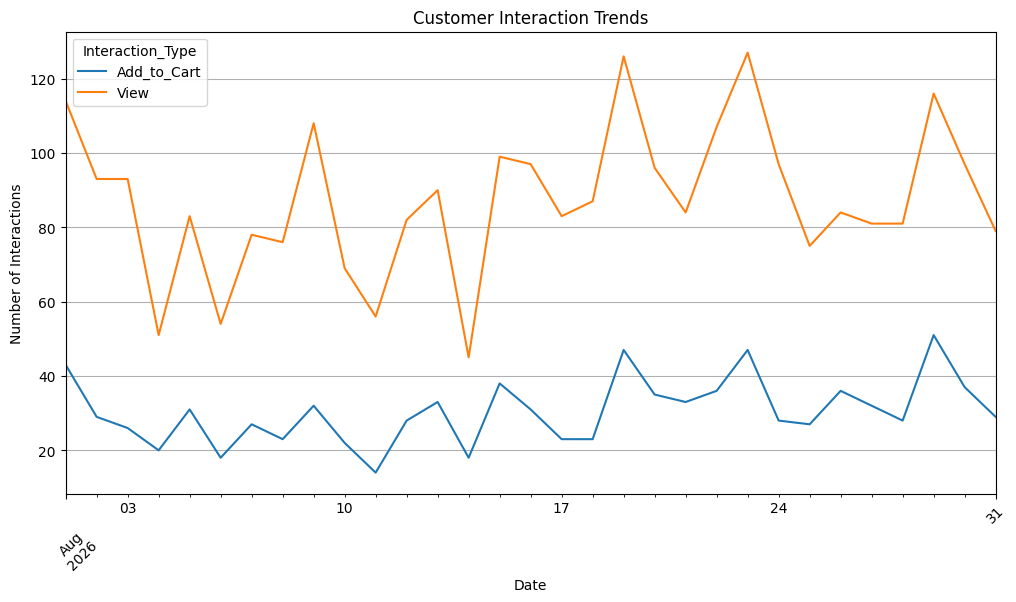

In [20]:
import matplotlib.pyplot as plt

daily_interactions["Date"] = pd.to_datetime(
    daily_interactions["Timestamp"]
)

pivot = daily_interactions.pivot(
    index="Date",
    columns="Interaction_Type",
    values="Count"
).fillna(0)

pivot.plot(figsize=(12, 6))

plt.title("Customer Interaction Trends")
plt.xlabel("Date")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [21]:
# Daily number of views and cart additions

daily = (
    interactions
    .groupby([
        interactions["Timestamp"].dt.date,
        "Interaction_Type"
    ])
    .size()
    .unstack(fill_value=0)
)

print(daily)

Interaction_Type  Add_to_Cart  View
Timestamp                          
2026-08-01                 43   114
2026-08-02                 29    93
2026-08-03                 26    93
2026-08-04                 20    51
2026-08-05                 31    83
2026-08-06                 18    54
2026-08-07                 27    78
2026-08-08                 23    76
2026-08-09                 32   108
2026-08-10                 22    69
2026-08-11                 14    56
2026-08-12                 28    82
2026-08-13                 33    90
2026-08-14                 18    45
2026-08-15                 38    99
2026-08-16                 31    97
2026-08-17                 23    83
2026-08-18                 23    87
2026-08-19                 47   126
2026-08-20                 35    96
2026-08-21                 33    84
2026-08-22                 36   107
2026-08-23                 47   127
2026-08-24                 28    97
2026-08-25                 27    75
2026-08-26                 3

In [22]:
daily["Total_Interactions"] = daily.sum(axis=1)

print(
    daily.sort_values(
        "Total_Interactions",
        ascending=False
    ).head(10)
)

Interaction_Type  Add_to_Cart  View  Total_Interactions
Timestamp                                              
2026-08-23                 47   127                 174
2026-08-19                 47   126                 173
2026-08-29                 51   116                 167
2026-08-01                 43   114                 157
2026-08-22                 36   107                 143
2026-08-09                 32   108                 140
2026-08-15                 38    99                 137
2026-08-30                 37    97                 134
2026-08-20                 35    96                 131
2026-08-16                 31    97                 128


In [23]:
daily_orders = (
    orders
    .groupby(
        orders["Order_Timestamp"].dt.date
    )
    .agg(
        Orders=("Order_ID", "count"),
        Quantity=("Quantity", "sum"),
        Revenue=("Total_Amount", "sum")
    )
)

print(daily_orders)

                 Orders  Quantity  Revenue
Order_Timestamp                           
2026-08-01           15        22     3180
2026-08-02           13        15     1977
2026-08-03            6         9     1004
2026-08-04            6         7      544
2026-08-05            9        11      943
2026-08-06            6         9     1324
2026-08-07            8         8     1224
2026-08-08            6         8      882
2026-08-09           11        19     2457
2026-08-10            5         8     1215
2026-08-11            7        11     1081
2026-08-12           11        14     1772
2026-08-13           14        15     1912
2026-08-14            5         6      796
2026-08-15           15        24     3546
2026-08-16           13        21     2499
2026-08-17           12        17     1687
2026-08-18            3         6      950
2026-08-19           11        13     1846
2026-08-20           14        22     1958
2026-08-21            8        15     2239
2026-08-22 

In [24]:
daily_combined = daily.join(
    daily_orders,
    how="left"
)

daily_combined[["Orders", "Quantity", "Revenue"]] = (
    daily_combined[["Orders", "Quantity", "Revenue"]]
    .fillna(0)
)

daily_combined["Interaction_to_Order"] = (
    daily_combined["Total_Interactions"]
    / daily_combined["Orders"].replace(0, 1)
)

print(daily_combined)

            Add_to_Cart  View  Total_Interactions  Orders  Quantity  Revenue  \
Timestamp                                                                      
2026-08-01           43   114                 157      15        22     3180   
2026-08-02           29    93                 122      13        15     1977   
2026-08-03           26    93                 119       6         9     1004   
2026-08-04           20    51                  71       6         7      544   
2026-08-05           31    83                 114       9        11      943   
2026-08-06           18    54                  72       6         9     1324   
2026-08-07           27    78                 105       8         8     1224   
2026-08-08           23    76                  99       6         8      882   
2026-08-09           32   108                 140      11        19     2457   
2026-08-10           22    69                  91       5         8     1215   
2026-08-11           14    56           

In [25]:
# Create product-level analysis

# Views
views = (
    interactions[interactions["Interaction_Type"] == "View"]
    .groupby("Product_ID")
    .size()
    .rename("Views")
)

# Cart additions
cart = (
    interactions[interactions["Interaction_Type"] == "Add_to_Cart"]
    .groupby("Product_ID")
    .size()
    .rename("Cart_Adds")
)

# Orders
order_summary = (
    orders.groupby("Product_ID")
    .agg(
        Orders=("Order_ID", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Total_Amount", "sum")
    )
)

# Latest inventory
latest_inventory = (
    inventory.sort_values("Date")
    .groupby("Product_ID")
    .tail(1)
    .set_index("Product_ID")
)

# Combine everything
analysis = products.set_index("Product_ID")

analysis = analysis.join(views)
analysis = analysis.join(cart)
analysis = analysis.join(order_summary)
analysis = analysis.join(
    latest_inventory[["Closing_Stock", "Stock_Status"]]
)

# Replace missing values
analysis[
    ["Views", "Cart_Adds", "Orders", "Quantity_Sold", "Revenue"]
] = analysis[
    ["Views", "Cart_Adds", "Orders", "Quantity_Sold", "Revenue"]
].fillna(0)

# Cart-to-view conversion
analysis["Cart_Rate_%"] = (
    analysis["Cart_Adds"] / analysis["Views"] * 100
).fillna(0)

# Cart-to-order gap
analysis["Cart_Order_Gap"] = (
    analysis["Cart_Adds"] - analysis["Orders"]
)

# Show most interesting products
print(
    analysis[
        [
            "Product_Name",
            "Views",
            "Cart_Adds",
            "Orders",
            "Quantity_Sold",
            "Closing_Stock",
            "Stock_Status",
            "Cart_Rate_%",
            "Cart_Order_Gap"
        ]
    ]
    .sort_values("Cart_Adds", ascending=False)
    .to_string()
)


                      Product_Name  Views  Cart_Adds  Orders  Quantity_Sold  Closing_Stock  Stock_Status  Cart_Rate_%  Cart_Order_Gap
Product_ID                                                                                                                           
P017              Orange Juice 1 L    164         75      12             16              6     Low Stock    45.731707              63
P013        Instant Noodles 4-Pack    172         67      11             17              4      Critical    38.953488              56
P026        Laundry Detergent 1 kg    209         45       4              6             10     Low Stock    21.531100              41
P015                   Pasta 500 g    120         41      14             24              9     Low Stock    34.166667              27
P030              Bath Soap 4-Pack    139         41       9             15              0  Out of Stock    29.496403              32
P031              Toothpaste 150 g     97         41       8  

In [26]:
# Create a simple risk score

analysis["Risk_Score"] = 0

# High customer interest
analysis.loc[
    analysis["Views"] >= analysis["Views"].quantile(0.75),
    "Risk_Score"
] += 25

# High cart additions
analysis.loc[
    analysis["Cart_Adds"] >= analysis["Cart_Adds"].quantile(0.75),
    "Risk_Score"
] += 25

# Low conversion from cart to order
analysis["Order_Conversion_%"] = (
    analysis["Orders"] / analysis["Cart_Adds"] * 100
).fillna(0)

analysis.loc[
    analysis["Order_Conversion_%"] < 30,
    "Risk_Score"
] += 25

# Inventory problem
analysis.loc[
    analysis["Stock_Status"].isin(
        ["Critical", "Out of Stock"]
    ),
    "Risk_Score"
] += 25

# Show highest-risk products
risk_products = analysis.sort_values(
    "Risk_Score",
    ascending=False
)

print(
    risk_products[
        [
            "Product_Name",
            "Views",
            "Cart_Adds",
            "Orders",
            "Order_Conversion_%",
            "Closing_Stock",
            "Stock_Status",
            "Risk_Score"
        ]
    ].head(10).to_string()
)


                      Product_Name  Views  Cart_Adds  Orders  Order_Conversion_%  Closing_Stock  Stock_Status  Risk_Score
Product_ID                                                                                                               
P030              Bath Soap 4-Pack    139         41       9           21.951220              0  Out of Stock         100
P013        Instant Noodles 4-Pack    172         67      11           16.417910              4      Critical         100
P017              Orange Juice 1 L    164         75      12           16.000000              6     Low Stock          75
P026        Laundry Detergent 1 kg    209         45       4            8.888889             10     Low Stock          75
P031              Toothpaste 150 g     97         41       8           19.512195             11     Low Stock          75
P022              Mixed Nuts 200 g     90         31       8           25.806452             11     Low Stock          50
P009                  Ba

In [27]:
# Daily customer activity

daily_activity = (
    interactions
    .groupby(interactions["Timestamp"].dt.date)
    .agg(
        Total_Interactions=("Interaction_ID", "count")
    )
)

# Daily orders
daily_orders = (
    orders
    .groupby(orders["Order_Timestamp"].dt.date)
    .agg(
        Orders=("Order_ID", "count"),
        Revenue=("Total_Amount", "sum")
    )
)

# Combine
daily_analysis = daily_activity.join(
    daily_orders,
    how="outer"
).fillna(0)

print(daily_analysis)

            Total_Interactions  Orders  Revenue
Timestamp                                      
2026-08-01               157.0      15     3180
2026-08-02               122.0      13     1977
2026-08-03               119.0       6     1004
2026-08-04                71.0       6      544
2026-08-05               114.0       9      943
2026-08-06                72.0       6     1324
2026-08-07               105.0       8     1224
2026-08-08                99.0       6      882
2026-08-09               140.0      11     2457
2026-08-10                91.0       5     1215
2026-08-11                70.0       7     1081
2026-08-12               110.0      11     1772
2026-08-13               123.0      14     1912
2026-08-14                63.0       5      796
2026-08-15               137.0      15     3546
2026-08-16               128.0      13     2499
2026-08-17               106.0      12     1687
2026-08-18               110.0       3      950
2026-08-19               173.0      11  

In [28]:
# Calculate average and standard deviation

mean_activity = daily_analysis["Total_Interactions"].mean()
std_activity = daily_analysis["Total_Interactions"].std()

print("Average daily interactions:", mean_activity)
print("Standard deviation:", std_activity)

Average daily interactions: 114.15625
Standard deviation: 34.682066924118466


In [29]:
daily_analysis["Z_Score"] = (
    daily_analysis["Total_Interactions"] - mean_activity
) / std_activity

print(
    daily_analysis[
        daily_analysis["Z_Score"].abs() > 2
    ]
)

            Total_Interactions  Orders  Revenue   Z_Score
Timestamp                                                
2026-09-01                 0.0       1      120 -3.291507


In [30]:
# Find unusual customer-activity days

mean_activity = daily_analysis["Total_Interactions"].mean()
std_activity = daily_analysis["Total_Interactions"].std()

daily_analysis["Z_Score"] = (
    daily_analysis["Total_Interactions"] - mean_activity
) / std_activity

suspicious_days = daily_analysis[
    daily_analysis["Z_Score"].abs() >= 2
].sort_values("Z_Score")

print("SUSPICIOUS DAYS:")
print(suspicious_days)

SUSPICIOUS DAYS:
            Total_Interactions  Orders  Revenue   Z_Score
Timestamp                                                
2026-09-01                 0.0       1      120 -3.291507


In [31]:
print(
    daily_analysis[
        ["Total_Interactions", "Orders", "Revenue", "Z_Score"]
    ].sort_values("Z_Score")
)

            Total_Interactions  Orders  Revenue   Z_Score
Timestamp                                                
2026-09-01                 0.0       1      120 -3.291507
2026-08-14                63.0       5      796 -1.475006
2026-08-11                70.0       7     1081 -1.273172
2026-08-04                71.0       6      544 -1.244339
2026-08-06                72.0       6     1324 -1.215506
2026-08-10                91.0       5     1215 -0.667672
2026-08-08                99.0       6      882 -0.437005
2026-08-25               102.0       6      646 -0.350505
2026-08-07               105.0       8     1224 -0.264005
2026-08-17               106.0      12     1687 -0.235172
2026-08-31               108.0      10     1285 -0.177505
2026-08-28               109.0       5     1058 -0.148672
2026-08-18               110.0       3      950 -0.119839
2026-08-12               110.0      11     1772 -0.119839
2026-08-27               113.0       6      798 -0.033339
2026-08-05    

In [32]:
inventory_daily = (
    inventory
    .groupby(["Date", "Stock_Status"])
    .size()
    .unstack(fill_value=0)
)

print(inventory_daily)

Stock_Status  Critical  Healthy  Low Stock  Out of Stock
Date                                                    
2026-08-01           0       14         22             0
2026-08-02           0       13         23             0
2026-08-03           0       13         23             0
2026-08-04           0       13         23             0
2026-08-05           0       15         21             0
2026-08-06           0       15         21             0
2026-08-07           0       15         21             0
2026-08-08           0       15         21             0
2026-08-09           0       16         20             0
2026-08-10           0       15         21             0
2026-08-11           0       14         22             0
2026-08-12           1       14         21             0
2026-08-13           0       15         21             0
2026-08-14           0       15         21             0
2026-08-15           0       14         22             0
2026-08-16           0       14

In [33]:
# Calculate percentages

analysis["Cart_Rate"] = (
    analysis["Cart_Adds"] / analysis["Views"].replace(0, 1)
) * 100

analysis["Order_Rate"] = (
    analysis["Orders"] / analysis["Cart_Adds"].replace(0, 1)
) * 100

# Demand gap
analysis["Demand_Gap"] = (
    analysis["Cart_Adds"] - analysis["Orders"]
)

# Create risk score
analysis["Risk_Score"] = 0

# High views
analysis.loc[
    analysis["Views"] >= analysis["Views"].quantile(0.75),
    "Risk_Score"
] += 20

# High cart additions
analysis.loc[
    analysis["Cart_Adds"] >= analysis["Cart_Adds"].quantile(0.75),
    "Risk_Score"
] += 30

# Low order conversion
analysis.loc[
    analysis["Order_Rate"] < 30,
    "Risk_Score"
] += 20

# Inventory problem
analysis.loc[
    analysis["Stock_Status"].isin(["Critical", "Out of Stock"]),
    "Risk_Score"
] += 30

print(
    analysis[
        [
            "Product_Name",
            "Views",
            "Cart_Adds",
            "Orders",
            "Closing_Stock",
            "Stock_Status",
            "Risk_Score"
        ]
    ]
    .sort_values("Risk_Score", ascending=False)
    .head(10)
)

                      Product_Name  Views  Cart_Adds  Orders  Closing_Stock  \
Product_ID                                                                    
P030              Bath Soap 4-Pack    139         41       9              0   
P013        Instant Noodles 4-Pack    172         67      11              4   
P017              Orange Juice 1 L    164         75      12              6   
P026        Laundry Detergent 1 kg    209         45       4             10   
P031              Toothpaste 150 g     97         41       8             11   
P009                  Bananas 1 kg     86         32       9             30   
P015                   Pasta 500 g    120         41      14              9   
P022              Mixed Nuts 200 g     90         31       8             11   
P034          Garbage Bags 30-Pack     85         36      12             22   
P023                 Cookies 200 g     79         32      12             15   

            Stock_Status  Risk_Score  
Product_ID  

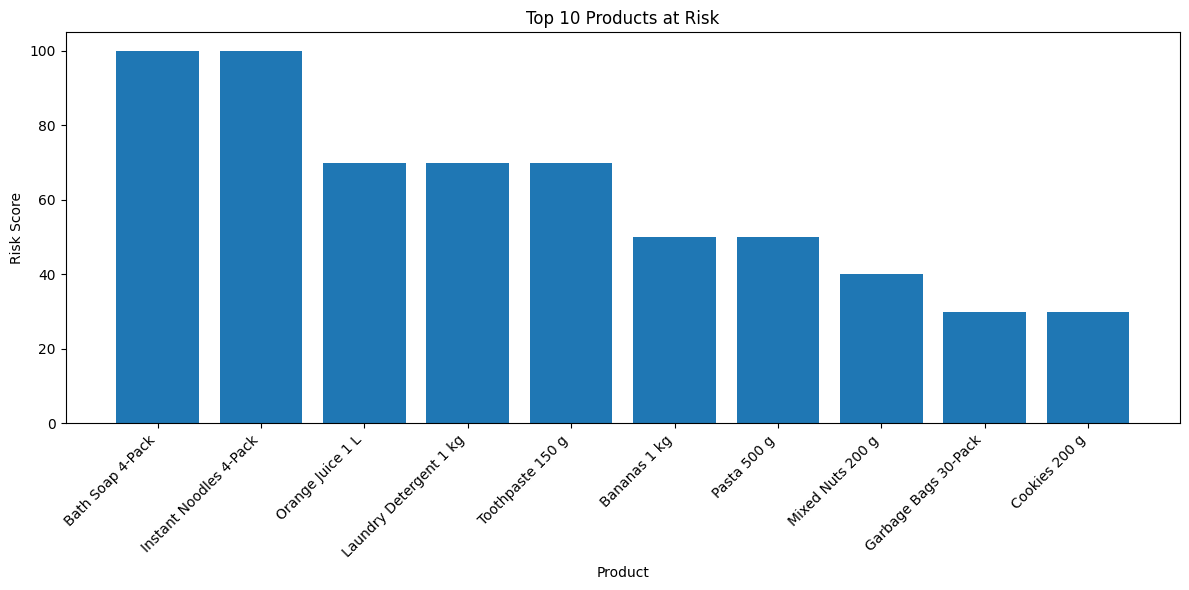

In [34]:
import matplotlib.pyplot as plt

top10 = analysis.sort_values(
    "Risk_Score",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["Product_Name"],
    top10["Risk_Score"]
)

plt.title("Top 10 Products at Risk")
plt.xlabel("Product")
plt.ylabel("Risk Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

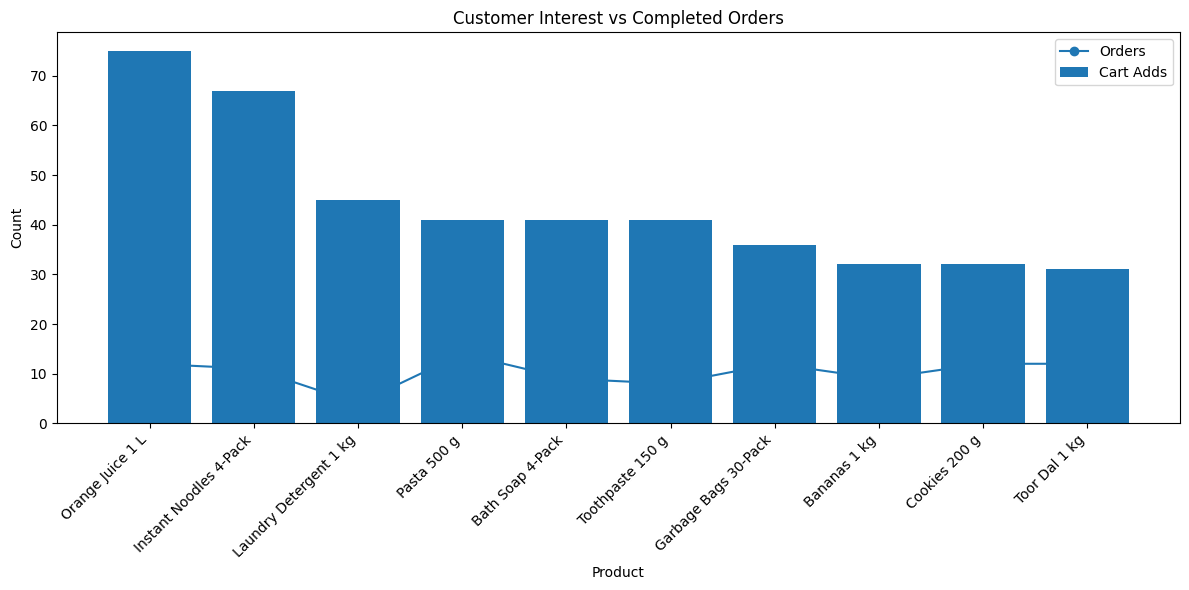

In [35]:
top = analysis.sort_values(
    "Cart_Adds",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(top["Product_Name"], top["Cart_Adds"], label="Cart Adds")
plt.plot(top["Product_Name"], top["Orders"], marker="o", label="Orders")

plt.title("Customer Interest vs Completed Orders")
plt.xlabel("Product")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
top_risk = analysis.sort_values(
    "Risk_Score",
    ascending=False
).head(10)

print(top_risk[
    [
        "Product_Name",
        "Views",
        "Cart_Adds",
        "Orders",
        "Closing_Stock",
        "Stock_Status",
        "Risk_Score"
    ]
].to_string(index=False))

          Product_Name  Views  Cart_Adds  Orders  Closing_Stock Stock_Status  Risk_Score
      Bath Soap 4-Pack    139         41       9              0 Out of Stock         100
Instant Noodles 4-Pack    172         67      11              4     Critical         100
      Orange Juice 1 L    164         75      12              6    Low Stock          70
Laundry Detergent 1 kg    209         45       4             10    Low Stock          70
      Toothpaste 150 g     97         41       8             11    Low Stock          70
          Bananas 1 kg     86         32       9             30      Healthy          50
           Pasta 500 g    120         41      14              9    Low Stock          50
      Mixed Nuts 200 g     90         31       8             11    Low Stock          40
  Garbage Bags 30-Pack     85         36      12             22      Healthy          30
         Cookies 200 g     79         32      12             15    Low Stock          30


In [37]:
mismatch = analysis[
    (analysis["Cart_Adds"] > analysis["Orders"]) &
    (analysis["Closing_Stock"] <= analysis["Closing_Stock"].median())
].copy()

mismatch["Demand_Gap_%"] = (
    (mismatch["Cart_Adds"] - mismatch["Orders"])
    / mismatch["Cart_Adds"].replace(0, 1)
) * 100

mismatch = mismatch.sort_values(
    "Demand_Gap_%",
    ascending=False
)

print(mismatch[
    [
        "Product_Name",
        "Views",
        "Cart_Adds",
        "Orders",
        "Closing_Stock",
        "Stock_Status",
        "Demand_Gap_%"
    ]
].head(10).to_string(index=False))

          Product_Name  Views  Cart_Adds  Orders  Closing_Stock Stock_Status  Demand_Gap_%
Laundry Detergent 1 kg    209         45       4             10    Low Stock     91.111111
      Orange Juice 1 L    164         75      12              6    Low Stock     84.000000
Instant Noodles 4-Pack    172         67      11              4     Critical     83.582090
      Toothpaste 150 g     97         41       8             11    Low Stock     80.487805
      Bath Soap 4-Pack    139         41       9              0 Out of Stock     78.048780
        Shampoo 340 ml     25          9       2             11    Low Stock     77.777778
   Chocolate Bar 100 g     66         21       5             14    Low Stock     76.190476
     Basmati Rice 5 kg     35         16       4             11    Low Stock     75.000000
      Mixed Nuts 200 g     90         31       8             11    Low Stock     74.193548
    Aluminium Foil 9 m     21          7       2             10    Low Stock     71.428571

In [38]:
p = top_risk.iloc[0]

print("🚨 TOP RISK PRODUCT")
print("--------------------------")
print("Product:", p["Product_Name"])
print("Views:", int(p["Views"]))
print("Cart Adds:", int(p["Cart_Adds"]))
print("Orders:", int(p["Orders"]))
print("Closing Stock:", int(p["Closing_Stock"]))
print("Stock Status:", p["Stock_Status"])
print("Risk Score:", int(p["Risk_Score"]))

🚨 TOP RISK PRODUCT
--------------------------
Product: Bath Soap 4-Pack
Views: 139
Cart Adds: 41
Orders: 9
Closing Stock: 0
Stock Status: Out of Stock
Risk Score: 100


NameError: name 'app' is not defined